In [16]:
import pandas as pd

X_test = pd.read_csv('./data_ml/X_test.csv')
X_train = pd.read_csv('./data_ml/X_train.csv')
y_test = pd.read_csv('./data_ml/y_test.csv')
y_train = pd.read_csv('./data_ml/y_train.csv')

X_train

,Profit after tax last year,Sales last year,positive_opm_last_year,profitable_last_year,material_cost_ratio,employee_cost_ratio,total_cost_ratio,depreciation_ratio,sales_growth,opm_change,log_sales,log_market_cap,Return on capital employed,asset_turnover,Interest,Depreciation
0,8.41,75.21,1,1,74.817179,14.040686,88.857865,0.837655,0.0,0.0,4.333493,5.642864,35.07,0.267394,0.76,0.63
1,0.11,22.29,1,1,150.000000,9.780170,159.780170,7.940781,0.0,0.0,3.148024,3.740285,8.39,0.542204,1.88,1.77
2,64.01,982.89,1,1,0.000000,49.525379,49.525379,1.627853,0.0,0.0,6.891514,6.948177,16.17,0.944859,18.36,16.00
3,35.00,252.94,1,1,4.720487,35.225745,39.946232,2.040009,0.0,0.0,5.537098,6.779979,21.82,0.287742,4.71,5.16
4,7.80,410.91,1,1,18.142659,4.538707,22.681366,1.564820,0.0,0.0,6.020805,5.151035,15.80,2.394441,9.59,6.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3212,1.32,20.90,1,1,0.000000,14.928230,14.928230,1.052632,0.0,0.0,3.086487,3.206398,22.25,0.882229,0.38,0.22
3213,4.19,60.69,1,1,129.939034,1.993739,131.932773,1.548855,0.0,0.0,4.122122,4.482550,122.06,0.693917,0.35,0.94
3214,20.41,236.02,1,1,26.590967,12.096433,38.687399,1.817643,0.0,0.0,5.468145,6.803550,18.11,0.262233,1.88,4.29
3215,77.63,1388.63,1,1,5.485262,6.601471,12.086733,1.000266,0.0,0.0,7.236793,7.675746,12.55,0.644546,63.90,13.89


# Sprawdź czy
- liczba wierszy sie zgadza X_train / y_train
- kolejność obserwacji (brak shuffle)
- czy y_train zawiera 4 klasy (negative, low, medium, high)

In [17]:
print(X_train.shape == y_train.shape, X_train.shape, y_train.shape)
print(X_test.shape == y_test.shape, X_test.shape, y_test.shape)


False (3217, 16) (3217, 1)
False (805, 16) (805, 1)


In [18]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

y_train_encoded

c:\Users\Kamil\Desktop\politechnika\python-financial-classification\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Kamil\Desktop\politechnika\python-financial-classification\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([2, 2, 2, ..., 2, 2, 1], shape=(3217,))

In [19]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
gradient_boosting = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gradient_boosting.fit(X_train, y_train_encoded)
y_pred_gb = gradient_boosting.predict(X_test)

test_accuracy = accuracy_score(y_test_encoded, y_pred_gb)
print(f'Test Accuracy: {test_accuracy*100:.4f}%')

print("Classification Report:")
print(classification_report(y_test_encoded, y_pred_gb))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_gb))

Test Accuracy: 81.3665%
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       110
           1       0.87      0.81      0.84       273
           2       0.68      0.71      0.69       221
           3       0.81      0.83      0.82       201

    accuracy                           0.81       805
   macro avg       0.84      0.84      0.84       805
weighted avg       0.82      0.81      0.81       805

Confusion Matrix:
[[109   1   0   0]
 [  1 221  43   8]
 [  0  31 158  32]
 [  0   1  33 167]]


In [20]:
import xgboost as xgb

xgb_classifier = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb_classifier.fit(X_train, y_train_encoded)
y_pred_xgb = xgb_classifier.predict(X_test)

test_accuracy_xgb = accuracy_score(y_test_encoded, y_pred_xgb)
print(f'XGBoost Test Accuracy: {test_accuracy_xgb*100:.4f}%')

print("Classification Report:")
print(classification_report(y_test_encoded, y_pred_xgb))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_xgb))

XGBoost Test Accuracy: 80.8696%
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       110
           1       0.87      0.81      0.84       273
           2       0.67      0.71      0.69       221
           3       0.79      0.81      0.80       201

    accuracy                           0.81       805
   macro avg       0.83      0.83      0.83       805
weighted avg       0.81      0.81      0.81       805

Confusion Matrix:
[[109   1   0   0]
 [  1 222  40  10]
 [  0  31 157  33]
 [  0   2  36 163]]


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
param_gird = {
    'n_estimators': [50, 100, 150,300 , 500],
    'max_depth': [3, 5, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1, 10],
    'reg_lambda': [1, 1.5, 2.0, 0.5, 0.7]
}

random_search = RandomizedSearchCV(estimator=xgb_classifier, param_distributions=param_gird, n_iter=100, scoring='accuracy', cv=10, verbose=2, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train_encoded)

best_xgb = random_search.best_estimator_

print("Best Hyperparameters:", random_search.best_params_)
print("Best Cross-Validation Score:", random_search.best_score_)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best Hyperparameters: {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 150, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best Cross-Validation Score: 0.8284108279638552


In [22]:
pred_xgb_hyper = best_xgb.predict(X_test)
test_accuracy_xgb_hyper = accuracy_score(y_test_encoded, pred_xgb_hyper)

print(f'XGBoost Test Accuracy: {test_accuracy_xgb_hyper*100:.4f}%')

print("Classification Report:")
print(classification_report(y_test_encoded, pred_xgb_hyper))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, pred_xgb_hyper))

XGBoost Test Accuracy: 81.9876%
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       110
           1       0.87      0.81      0.84       273
           2       0.68      0.74      0.71       221
           3       0.82      0.83      0.83       201

    accuracy                           0.82       805
   macro avg       0.84      0.84      0.84       805
weighted avg       0.82      0.82      0.82       805

Confusion Matrix:
[[108   1   0   1]
 [  1 221  44   7]
 [  0  29 164  28]
 [  0   2  32 167]]


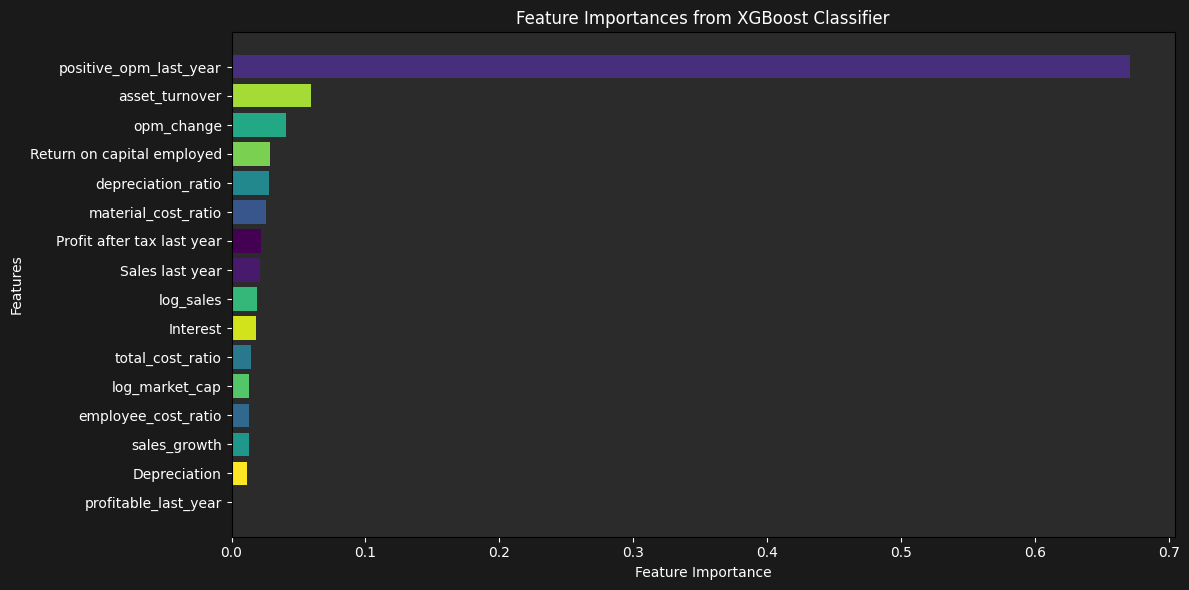

In [25]:
feature_importances = best_xgb.feature_importances_ 
features = X_train.columns

# sort and plot
import matplotlib.pyplot as plt
import numpy as np

indices = np.argsort(feature_importances)[::-1]
y_pos = np.arange(len(features))

fig, ax = plt.subplots(figsize=(12, 6))

# Colors aligned with sorted features
colors_sorted = colors[indices]

# Horizontal bar chart
ax.barh(y_pos, feature_importances[indices], align='center', color=colors_sorted)

# Invert y-axis so the most important is on top
ax.set_yticks(y_pos)
ax.set_yticklabels(np.array(features)[indices])
ax.invert_yaxis()

ax.set_xlabel('Feature Importance', color='white')
ax.set_ylabel('Features', color='white')
ax.set_title('Feature Importances from XGBoost Classifier', color='white')

# Set darker background
ax.set_facecolor('#2b2b2b')
fig.patch.set_facecolor('#1a1a1a')
ax.tick_params(colors='white')

plt.tight_layout()
plt.show()